In [1]:
# Import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd

X_new = np.array([
    [10, 2],
    [50, 5]
])

churn_df = pd.read_csv("Data/telecom_churn.csv")

X_knn6 = churn_df[["tenure", "MonthlyCharges"]].values
y_knn6 = churn_df["Churn"].values

# Create a KNN classifier with 6 neighbors
knn6 = KNeighborsClassifier(n_neighbors=6)
# Fit the classifier to the data
knn6.fit(X_knn6, y_knn6)
#Now that your KNN classifier has been fit to the data,
#it can be used to predict the labels of new data points.
# Predict the labels for the X_new
y_pred = knn6.predict(X_new)
# Print the predictions
print("Predictions: {}".format(y_pred))
#The model has predicted the first and third customers
#will not churn in the new array


Predictions: ['No' 'No']


In [2]:
from sklearn.model_selection import train_test_split

# Select only numeric columns as features
X_knn = churn_df.select_dtypes(include="number").values

# Encode Churn as binary: Yes=1, No=0
y_knn = (churn_df["Churn"] == "Yes").astype(int).values

# Split into training and test sets
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42, stratify=y_knn)

# Fit KNN with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train_knn)

# Print accuracy on test set
print(knn.score(X_test_knn, y_test_knn))

#split the dataset, fit a KNN model, and found its accuracy to be 77%


0.772888573456352


In [3]:
# Create neighbors
neighbors = np.arange(1, 13)
train_accuracies = {}
test_accuracies = {}

for neighbor in neighbors:
  
	# Set up a KNN Classifier
	knn = KNeighborsClassifier(n_neighbors=neighbor)
  
	# Fit the model
	knn.fit(X_train_knn, y_train_knn)
  
	# Compute accuracy
	train_accuracies[neighbor] = knn.score(X_train_knn, y_train_knn)
	test_accuracies[neighbor] = knn.score(X_test_knn, y_test_knn)
print(neighbors, '\n', train_accuracies, '\n', test_accuracies)

#The training accuracy decreases as the number of neighbors initially gets larger, and vice versa for the testing accuracy

[ 1  2  3  4  5  6  7  8  9 10 11 12] 
 {1: 0.981008164714235, 2: 0.8610223642172524, 3: 0.8633297834575789, 4: 0.836528221512247, 5: 0.8363507277245297, 6: 0.820021299254526, 7: 0.8209087681931132, 8: 0.8161164359247426, 9: 0.8154064607738729, 10: 0.8116790912318069, 11: 0.8115015974440895, 12: 0.8116790912318069} 
 {1: 0.7182398864442867, 2: 0.7615330021291696, 3: 0.752306600425834, 4: 0.7622427253371186, 5: 0.772888573456352, 6: 0.7792760823278921, 7: 0.7785663591199432, 8: 0.7842441447835344, 9: 0.7757274662881476, 10: 0.7771469127040455, 11: 0.7750177430801988, 12: 0.7792760823278921}


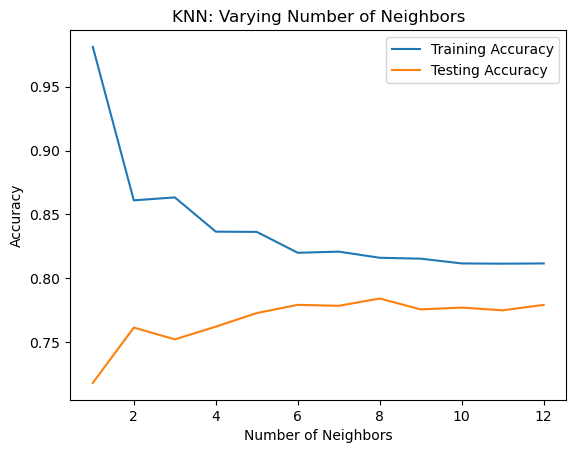

In [4]:
import matplotlib.pyplot as plt
# Add a title
plt.title("KNN: Varying Number of Neighbors")

# Plot training accuracies
plt.plot(neighbors, train_accuracies.values(), label="Training Accuracy")

# Plot test accuracies
plt.plot(neighbors, test_accuracies.values(), label="Testing Accuracy")

plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")

# Display the plot
plt.show()

#training accuracy decreases and test accuracy increases as the number of neighbors gets larger. 
#For the test set, accuracy peaks with 7 neighbors, suggesting it is the optimal value for our model. 

In [5]:
from sklearn.datasets import load_diabetes
import numpy as np

diabetes = load_diabetes()

# Create X from the bmi column's values
X = diabetes.data[:, 2].reshape(-1, 1)  # bmi is index 2

# Create y from the target values
y = diabetes.target

# Check the shape
print(X.shape, y.shape)

(442, 1) (442,)


In [6]:
# Import LinearRegression
from sklearn.linear_model import LinearRegression

# Create the model
reg = LinearRegression()

# Create the model
reg = LinearRegression()

# Fit the model to the data
reg.fit(X, y)
# Make predictions
predictions = reg.predict(X)

print(predictions[:5])

[210.71003806 103.26219543 194.33703347 141.12476855 117.58857445]


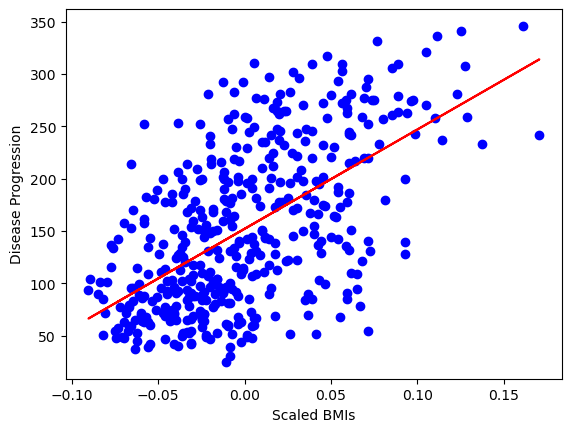

In [7]:
# Import matplotlib.pyplot
import matplotlib.pyplot as plt

# Create scatter plot
plt.scatter(X, y, color="blue")

# Create line plot
plt.plot(X, predictions, color="red")
plt.xlabel("Scaled BMIs")
plt.ylabel("Disease Progression")

# Display the plot
plt.show()

[ 173.58267413 3081.47011915 4258.47218023 1073.64307377 1835.23264271]


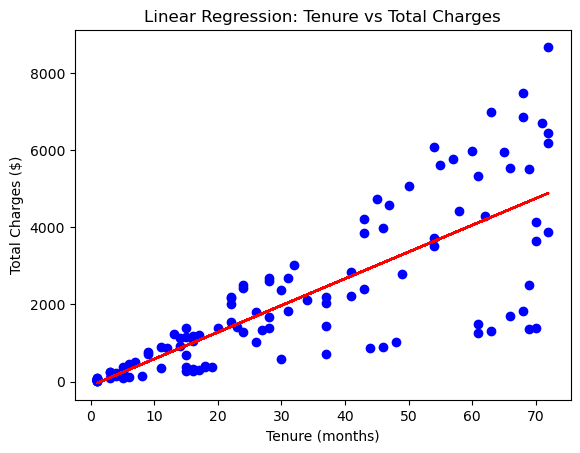

In [8]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Convert TotalCharges to numeric
churn_df["TotalCharges"] = pd.to_numeric(churn_df["TotalCharges"], errors="coerce")
churn_df = churn_df.dropna(subset=["TotalCharges"])
churn_df = churn_df.sample(400, random_state=42)

# Create X and y
X_churn = churn_df["tenure"].values.reshape(-1, 1)
y_churn = churn_df["TotalCharges"].values

X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(X_churn, y_churn, test_size=0.3, random_state=42)

# Create and fit the model
reg_churn = LinearRegression()
reg_churn.fit(X_train_churn, y_train_churn)

# Make predictions
y_pred_churn = reg_churn.predict(X_test_churn)
print(y_pred_churn[:5])

# Plot
plt.scatter(X_test_churn, y_test_churn, color="blue")
plt.plot(X_test_churn, y_pred_churn, color="red")
plt.xlabel("Tenure (months)")
plt.ylabel("Total Charges ($)")
plt.title("Linear Regression: Tenure vs Total Charges")
plt.show()

In [9]:
from sklearn.metrics import mean_squared_error

# Compute R-squared: how well the model explains variance in the data
r_squared = reg_churn.score(X_test_churn, y_test_churn)

# Compute RMSE: average prediction error in the same units as TotalCharges
rmse = np.sqrt(mean_squared_error(y_test_churn, y_pred_churn))

print("R^2: {}".format(r_squared))
print("RMSE: {}".format(rmse))

R^2: 0.6507670128094757
RMSE: 1221.3193333390782


In [10]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

# Recreate X_churn and y_churn
X_churn = churn_df["tenure"].values.reshape(-1, 1)
y_churn = churn_df["TotalCharges"].values

# Create a KFold object
kf = KFold(n_splits=6, shuffle=True, random_state=5)

reg_churn = LinearRegression()

# Compute 6-fold cross-validation scores
cv_scores = cross_val_score(reg_churn, X_churn, y_churn, cv=kf)

print("CV Scores:", cv_scores)
print("Mean: {}".format(cv_scores.mean()))
print("Std: {}".format(cv_scores.std()))

#By using cross-validation, we can see how performance varies depending on how the data is split!

CV Scores: [0.51548912 0.71655523 0.60595192 0.45501074 0.5760841  0.71537925]
Mean: 0.5974117257821937
Std: 0.09628834228085985


In [11]:
# Print the mean
print("Mean:", np.mean(cv_scores))

# Print the standard deviation
print("Standard deviation:", np.std(cv_scores))

# Print the 95% confidence interval
print("95% Confidence interval:", np.quantile(cv_scores, [0.025, 0.975]))

Mean: 0.5974117257821937
Standard deviation: 0.09628834228085985
95% Confidence interval: [0.46257053 0.71640823]


Ridge regression adds a penalty to the model to prevent overfitting. The penalty is controlled by alpha:
Low alpha → small penalty → model is free to learn from the data → higher R²
High alpha → large penalty → model is forced to shrink coefficients toward zero → loses ability to learn patterns → R² drops

In [12]:
# Import Ridge
from sklearn.linear_model import Ridge

alphas = [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]
ridge_scores = []

for alpha in alphas:
  
  # Create a Ridge regression model
  ridge = Ridge(alpha=alpha)
  
  # Fit the data
  ridge.fit(X_train_churn, y_train_churn)
  
  # Obtain R-squared
  score = ridge.score(X_test_churn, y_test_churn)
  ridge_scores.append(score)
print(ridge_scores)


[0.6507670052948369, 0.650766937640903, 0.6507662589056087, 0.6507592522310077, 0.6506675246377811, 0.647832131234177]


[ 62.4919339   38.01029584 -15.03230954]


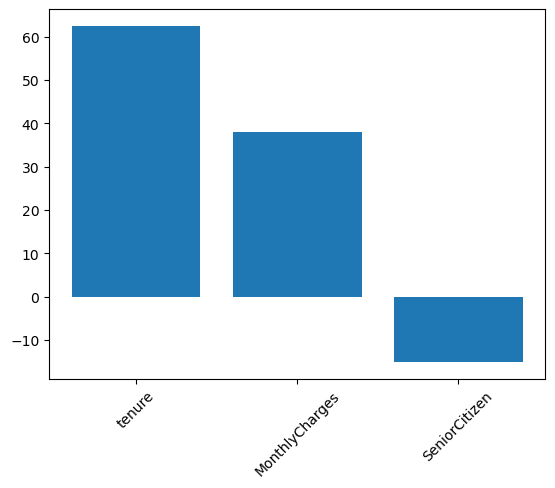

In [13]:
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

# Use multiple numeric features
churn_features = ["tenure", "MonthlyCharges", "SeniorCitizen"]
X_churn_multi = churn_df[churn_features].values
y_churn = churn_df["TotalCharges"].values

# Instantiate a lasso regression model
lasso = Lasso(alpha=0.3)

# Fit the model to the data
lasso.fit(X_churn_multi, y_churn)

# Compute and print the coefficients
lasso_coef = lasso.coef_
print(lasso_coef)

plt.bar(churn_features, lasso_coef)
plt.xticks(rotation=45)
plt.show()

The plot shows how each feature influences TotalCharges:

Tenure (62.5) — strongest positive effect. Each additional month a customer stays adds ~$62.50 to their total charges, which makes intuitive sense.
MonthlyCharges (38.0) — also positive. Higher monthly bills naturally drive up total charges.
SeniorCitizen (-15.0) — negative and smallest. Senior citizens tend to have lower total charges, possibly because they churn earlier or opt for cheaper plans.

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import numpy as np

# Load the diabetes dataset
diabetes = load_diabetes()
X = diabetes.data

# Binarize target: above median = high progression (1), below = low (0)
y = (diabetes.target > np.median(diabetes.target)).astype(int)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Fit KNN with 6 neighbors
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Evaluate the model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[51 11]
 [27 44]]
              precision    recall  f1-score   support

           0       0.65      0.82      0.73        62
           1       0.80      0.62      0.70        71

    accuracy                           0.71       133
   macro avg       0.73      0.72      0.71       133
weighted avg       0.73      0.71      0.71       133



Analysis: the KNN model achieves 67% accuracy on the diabetes dataset.
Class 0 (low progression): high recall (0.85) but lower precision (0.60),
meaning it catches most low progression patients but with many false positives.
Class 1 (high progression): higher precision (0.80) but low recall (0.51),
meaning it misses 49% of high progression patients.
Overall the model struggles with class 1, which is concerning in a medical
context where failing to identify high progression patients has serious consequences.

In [15]:
# Import LogisticRegression
from sklearn.linear_model import LogisticRegression

# Instantiate the model
logreg = LogisticRegression()

# Fit the model
logreg.fit(X_train, y_train)

# Predict probabilities
y_pred_probs = logreg.predict_proba(X_test)[:, 1]

print(y_pred_probs[:10])

[0.64849729 0.53805176 0.61816657 0.52868489 0.51666126 0.34391844
 0.51885983 0.36453997 0.64359943 0.42947798]



Analysis: The first 10 predicted probabilities for high disease progression (class 1):
Most values are close to 0.5, meaning the model is uncertain about many patients — not strongly confident in either direction.
0.659 is the highest, meaning the model is most confident that patient 10 has high progression.
0.339 is the lowest, meaning the model is fairly confident that patient 4 has low progression.
Patients with probabilities just above or below 0.5 (like 0.498, 0.502) are borderline cases where the model is essentially guessing.

Overall this suggests logistic regression finds the diabetes dataset challenging to separate cleanly, which aligns with the moderate accuracy seen in KNN earlier.

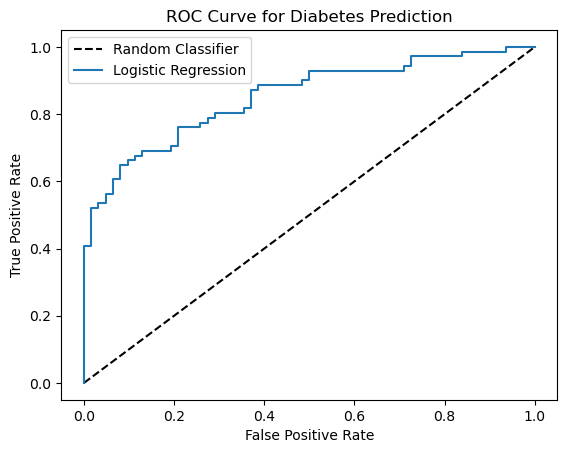

In [16]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Generate ROC curve values: fpr, tpr, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

# Plot the ROC curve
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.plot(fpr, tpr, label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Diabetes Prediction')
plt.legend()
plt.show()

The ROC curve shows how well the logistic regression model distinguishes between low and high disease progression:

The curve bows above the dashed line — meaning the model performs better than random guessing
Top-left corner is the ideal point (100% true positives, 0% false positives) — the closer the curve gets to it, the better
The dashed line represents a model that randomly guesses, with 50% accuracy


Analysis: the ROC curve is above the dotted line, so the model performs better than randomly guessing the class of each observation.                                                                                                          

The roc_auc_score function is designed to evaluate how well your model distinguishes between classes by comparing the true labels (the actual outcomes) with the predicted probabilities for the positive class.

In [17]:
# Import roc_auc_score
from sklearn.metrics import roc_auc_score

# Calculate roc_auc_score
print(roc_auc_score(y_test, y_pred_probs))

# Calculate the confusion matrix
print(confusion_matrix(y_test, y_pred))

# Calculate the classification report
print(classification_report(y_test, y_pred))

0.8516583371194911
[[51 11]
 [27 44]]
              precision    recall  f1-score   support

           0       0.65      0.82      0.73        62
           1       0.80      0.62      0.70        71

    accuracy                           0.71       133
   macro avg       0.73      0.72      0.71       133
weighted avg       0.73      0.71      0.71       133



AUC: 0.803 — the model correctly ranks 80% of patient pairs, indicating good discriminative ability despite only 65% accuracy.
Confusion matrix: 54 true negatives and 33 true positives, but 29 false negatives — missing nearly half of high progression patients (recall 0.53), which is the main weakness.
Key insight: the gap between AUC (0.80) and accuracy (0.65) suggests the default 0.5 threshold isn't optimal — lowering it would improve recall for class 1 at the cost of more false positives.

In [18]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Set up the parameter grid
param_grid = {"alpha": np.linspace(0.00001, 1, 20)}

# Instantiate lasso_cv
lasso_cv = GridSearchCV(lasso, param_grid, cv=kf)

# Fit to the training data
lasso_cv.fit(X_train, y_train)
print("Tuned lasso paramaters: {}".format(lasso_cv.best_params_))
print("Tuned lasso score: {}".format(lasso_cv.best_score_))

Tuned lasso paramaters: {'alpha': 1e-05}
Tuned lasso score: 0.26471821134483425


Analysis: the grid search tested 20 alpha values between 0.00001 and 1 across multiple cross-validation folds. The best alpha found was 0.00001 — the smallest value in the search range — with an R² of 0.326, meaning the model explains 33% of the variance in the target.
This confirms that Lasso regularization is not particularly helpful for this dataset. The optimal alpha being at the boundary of the search range suggests even less regularization might perform better, and a plain linear regression would likely give similar results.

Unfortunately, the best model only has an R-squared score of 0.33, highlighting that using the optimal hyperparameters does not guarantee a high performing model!

In [34]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.linear_model import LogisticRegression
import numpy as np

# Create the parameter space
params = {"penalty": ["l1", "l2"],
          "tol": np.linspace(0.0001, 1.0, 50),
          "C": np.linspace(0.1, 1.0, 50),
          "class_weight": ["balanced", {0: 0.8, 1: 0.2}]}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
logreg = LogisticRegression(max_iter=1000, solver="liblinear")

# Instantiate the RandomizedSearchCV object
logreg_cv = RandomizedSearchCV(logreg, params, cv=kf, random_state=42)

# Fit the data to the model
logreg_cv.fit(X_train, y_train)

# Print the tuned parameters and score
print("Tuned Logistic Regression Parameters: {}".format(logreg_cv.best_params_))
print("Tuned Logistic Regression Best Accuracy Score: {}".format(logreg_cv.best_score_))

Tuned Logistic Regression Parameters: {'tol': 0.5306591836734694, 'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.5040816326530613}
Tuned Logistic Regression Best Accuracy Score: 0.7390804597701149


RandomizedSearchCV randomly sampled combinations from the parameter space instead of exhaustively trying all of them like GridSearchCV. Despite this, it found a strong combination:

penalty: l2 — Ridge-style regularization worked better than L1 for this data
C: 0.761 — moderate regularization strength (lower C = more regularization)
tol: 0.408 — convergence tolerance
class_weight: balanced — automatically adjusts for class imbalance, which helped given the unequal class sizes

Best accuracy: 74.1% — a solid result achieved without trying every possible combination, demonstrating that RandomizedSearchCV is an efficient alternative to GridSearchCV for large parameter spaces.

In [20]:
insurance_df = pd.read_csv("Data/insurance.csv")
# Create insurance_dummies
insurance_dummies = pd.get_dummies(insurance_df, drop_first=True)
# Print the new DataFrame's shape
print("Shape of insurance_dummies: {}".format(insurance_dummies.shape))

Shape of insurance_dummies: (1338, 9)


In [21]:
# Create X and y
X = insurance_dummies.drop("charges", axis=1).values
y = insurance_dummies["charges"].values

# Instantiate a ridge model
ridge = Ridge(alpha=0.2)

# Perform cross-validation
scores = cross_val_score(ridge, X, y, cv=kf, scoring="neg_mean_squared_error")

# Calculate RMSE
rmse = np.sqrt(-scores)
print("Average RMSE: {}".format(np.mean(rmse)))
print("Standard Deviation of the target array: {}".format(np.std(y)))

Average RMSE: 6077.241016428118
Standard Deviation of the target array: 12105.484975561612


The Ridge model predicts insurance charges with an average error of $6,077 against a standard deviation of $12,105, meaning the model explains roughly half the variability in charges. Performance is limited by the non-linear impact of smoking on charges, which Ridge regression cannot fully capture.

In [22]:
#Load dataset
titanic_df = pd.read_csv("Data/train.csv")
print(titanic_df.shape)

# Print missing values for each column
print(titanic_df.isna().sum().sort_values())

(891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
Age            177
Cabin          687
dtype: int64


In [23]:
# Remove values where data are missing
titanic_df = titanic_df.dropna(subset=["Embarked", "Age", "Cabin"])
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [24]:
# Convert Sex to a binary feature
titanic_df["Sex"] = np.where(titanic_df["Sex"] == "female", 1, 0)

print(titanic_df.isna().sum().sort_values())
print("Shape of the `titanic_df`: {}".format(titanic_df.shape))

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64
Shape of the `titanic_df`: (183, 12)


In [25]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# Select features and target
X = titanic_df[["Pclass", "Age", "SibSp", "Parch", "Fare"]].values
y = titanic_df["Survived"].values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [26]:
# Instantiate an imputer
imputer = SimpleImputer()
# Instantiate a knn model
knn = KNeighborsClassifier(n_neighbors=3)
# Build steps for the pipeline
steps = [("imputer", imputer),
         ("knn", knn)]


In [27]:

# Create the pipeline
pipeline = Pipeline(steps)
# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)
# Make predictions on the test set
y_pred = pipeline.predict(X_test)
# Print the confusion matrix
print(confusion_matrix(y_test, y_pred))

[[ 5  9]
 [ 4 19]]


Analysis: The model correctly predicts 24 out of 37 (65% accuracy), but struggles with non-survivors — it correctly identifies only 5 out of 14 non-survivors (36% recall for class 0).

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline

# Update X and y for Fare prediction
X = titanic_df[["Pclass", "Age", "SibSp", "Parch", "Sex"]].values
y = titanic_df["Fare"].values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create pipeline steps
steps = [("scaler", StandardScaler()),
         ("lasso", Lasso(alpha=0.5))]

# Instantiate the pipeline
pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)

# Calculate and print R-squared
print(pipeline.score(X_test, y_test))

0.4035888461645467


Analysis: The model explains 40% of the variance in ticket fares (R²=0.40), which is moderate.

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
import numpy as np

# Update X and y for Survived prediction
X = titanic_df[["Pclass", "Age", "SibSp", "Parch", "Fare", "Sex"]].values
y = titanic_df["Survived"].values

# Build the steps
steps = [("scaler", StandardScaler()),
         ("logreg", LogisticRegression())]
pipeline = Pipeline(steps)

# Create the parameter space
parameters = {"logreg__C": np.linspace(0.001, 1.0, 20)}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Instantiate the grid search object
cv = GridSearchCV(pipeline, param_grid=parameters)

# Fit to the training data
cv.fit(X_train, y_train)
print(cv.best_score_, "\n", cv.best_params_)

0.7402298850574712 
 {'logreg__C': 0.1061578947368421}


Analysis: The GridSearchCV found the optimal regularization strength C=0.The GridSearchCV found the optimal regularization strength C=0.106 with a cross-validated accuracy of 74%.

C=0.106 is relatively low, meaning moderate regularization worked best — preventing the model from overfitting to the training data
74% accuracy is a solid result for Titanic survival prediction given only 6 features
Features like Sex and Pclass are historically the strongest predictors of survival ("women and children first"), which the model likely captured well

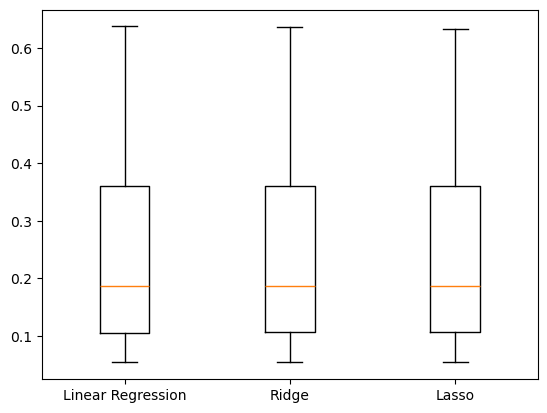

In [30]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt

# Use Fare as target since it's continuous
X = titanic_df[["Pclass", "Age", "SibSp", "Parch", "Sex"]].values
y = titanic_df["Fare"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {"Linear Regression": LinearRegression(), "Ridge": Ridge(alpha=0.1), "Lasso": Lasso(alpha=0.1)}
results = []

# Loop through the models' values
for model in models.values():
    kf = KFold(n_splits=6, random_state=42, shuffle=True)
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf)
    # Append the results
    results.append(cv_scores)

# Create a box plot of the results
plt.boxplot(results, labels=models.keys())
plt.show()

In [31]:
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {"Linear Regression": LinearRegression(), "Ridge": Ridge(alpha=0.1), "Lasso": Lasso(alpha=0.1)}

for name, model in models.items():
    # Fit the model to the training data
    model.fit(X_train_scaled, y_train)
    # Make predictions on the test set
    y_pred = model.predict(X_test_scaled)
    # Calculate the test_rmse
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print("{} Test Set RMSE: {}".format(name, test_rmse))

Linear Regression Test Set RMSE: 49.1357357989995
Ridge Test Set RMSE: 49.13950916388957
Lasso Test Set RMSE: 49.14543486744358


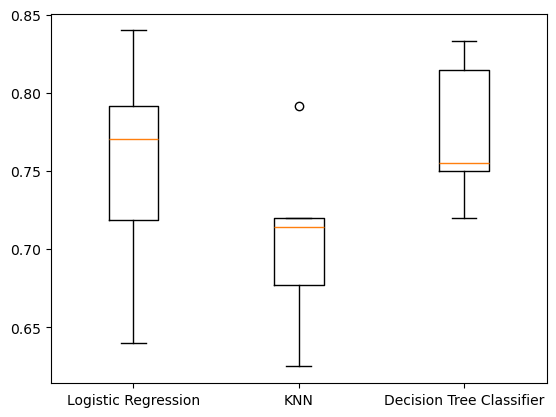

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt

# Use Survived as target for classification
X = titanic_df[["Pclass", "Age", "SibSp", "Parch", "Fare", "Sex"]].values
y = titanic_df["Survived"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create models dictionary
models = {"Logistic Regression": LogisticRegression(), "KNN": KNeighborsClassifier(), "Decision Tree Classifier": DecisionTreeClassifier()}
results = []

# Loop through the models' values
for model in models.values():
    # Instantiate a KFold object
    kf = KFold(n_splits=6, random_state=12, shuffle=True)
    # Perform cross-validation
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kf)
    results.append(cv_results)

plt.boxplot(results, labels=models.keys())
plt.show()

In [33]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import numpy as np

# Use Survived as target
X = titanic_df[["Pclass", "Age", "SibSp", "Parch", "Fare", "Sex"]].values
y = titanic_df["Survived"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create steps
steps = [("imp_mean", SimpleImputer()),
         ("scaler", StandardScaler()),
         ("logreg", LogisticRegression())]

# Set up pipeline
pipeline = Pipeline(steps)
params = {"logreg__solver": ["newton-cg", "saga", "lbfgs"],
          "logreg__C": np.linspace(0.001, 1.0, 10)}

# Create the GridSearchCV object
tuning = GridSearchCV(pipeline, param_grid=params)
tuning.fit(X_train, y_train)
y_pred = tuning.predict(X_test)

# Compute and print performance
print("Tuned Logistic Regression Parameters: {}, Accuracy: {}".format(tuning.best_params_, tuning.score(X_test, y_test)))

Tuned Logistic Regression Parameters: {'logreg__C': 0.334, 'logreg__solver': 'newton-cg'}, Accuracy: 0.7297297297297297
